# Figure 5g–i | Early high FC across efficient training strategies

本 notebook 保留原 Figure 5g–i 的三组分析：**SGD versus Adam（Fig. 5g）**、**without versus with BatchNorm（Fig. 5h）**，以及 **no residual、standard residual 和 FC-guided residual（Fig. 5i）**。

所有 loss、accuracy、FC 和 gradient 曲线均由至少 20 个独立初始化并重新训练的随机种子汇总，显示 seed 间均值和 95% CI。FC矩阵、网络图和单次指标柱状图只使用预先指定的 representative seed，作为结构示例而非推断统计。

In [73]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torchvision import transforms


def locate_mlp_dir():
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / 'mlp_early_high_fc_utils.py').exists():
            return root
        candidate = root / 'FC-IS_code' / 'MLP'
        if (candidate / 'mlp_early_high_fc_utils.py').exists():
            return candidate
    raise FileNotFoundError('Cannot locate FC-IS_code/MLP.')


MLP_DIR = locate_mlp_dir()
if str(MLP_DIR) not in sys.path:
    sys.path.insert(0, str(MLP_DIR))

from mlp_early_high_fc_utils import (
    ADAM_COLOR, BATCHNORM_COLOR, FC_RESIDUAL_COLOR, PLAIN_COLOR,
    RESIDUAL_COLOR, STANDARD_COLOR, PairExperimentConfig,
    ResidualExperimentConfig, collect_analysis_batch, export_figure,
    plot_pair_curves, plot_representative_matrices,
    plot_representative_metric_bars, plot_representative_networks,
    plot_residual_curves, run_or_load_pair_repeats,
    run_or_load_residual_repeats,
)

print({'python': platform.python_version(), 'torch': torch.__version__,
       'torchvision': torchvision.__version__, 'numpy': np.__version__})
print('MLP directory:', MLP_DIR)

{'python': '3.12.12', 'torch': '2.9.0+cu128', 'torchvision': '0.24.0+cu128', 'numpy': '2.3.4'}
MLP directory: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP


## Configuration

训练仍进行300个step。为控制20-seed分析的运行量，曲线默认每5个训练step评估一次；这只降低曲线采样密度，不改变训练、FC定义或比较条件。将 `evaluation_interval=1` 可恢复逐step评估。每个seed单独缓存，任务中断后可以继续。

In [2]:
DATA_ROOT = MLP_DIR / 'data'
RESULT_ROOT = MLP_DIR / 'results' / 'Figure5g_i_multiseed'
OUTPUT_ROOT = MLP_DIR / 'fig' / 'Figure5g_i_multiseed'
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SEEDS = tuple(range(20))
REPRESENTATIVE_SEED = 0
NUM_WORKERS = 2
OVERWRITE_PAIR_RESULTS = True
OVERWRITE_RESIDUAL_RESULTS = True  # set to False after the first successful stable-gate run
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# FC curve: fraction of strongest FC edges used for the top-FC mean.
# Changing this value changes stored curves and requires the relevant overwrite flag.
TOP_FC_CURVE_RATIO = 0.05

# Network visualization controls. These do not change the trained models.
NETWORK_TOP_EDGE_RATIO = 0.05  # 300-node graphs are usually clearer at 0.01-0.02
NETWORK_LAYOUT = 'kamada'  # 'kamada', 'spring', 'spectral', 'circular', or 'shell'
NETWORK_MODULE_SPACING = 1.6  # 1.0 keeps the raw layout; >1 separates module centroids
NETWORK_MIN_DEGREE = 2  # hide low-degree nodes to reduce visual clutter
NETWORK_NODE_COLOR = '#7f7f7f'  # one color for all modules
NETWORK_PLOT_OPTIONS = dict(
    top_ratio=NETWORK_TOP_EDGE_RATIO, layout=NETWORK_LAYOUT,
    module_spacing=NETWORK_MODULE_SPACING, min_degree=NETWORK_MIN_DEGREE,
    node_color=NETWORK_NODE_COLOR,
)

pair_config = PairExperimentConfig(
    seeds=SEEDS, representative_seed=REPRESENTATIVE_SEED,
    hidden_dims=(300, 300), batch_size=256, total_steps=300,
    evaluation_interval=5, learning_rate=0.05,
    adam_learning_rate=1e-3, top_fc_ratio=TOP_FC_CURVE_RATIO,
    fc_matrix_steps=(15, 20, 25), metric_step=25, analysis_samples=2000,
)
# Four interpretable FC-guidance parameters; scheduling details are internal.
FC_GATE_STRENGTH = 3.0
FC_GATE_TOP_FRACTION = 0.5
FC_COUPLING_STRENGTH = 0.80
FC_COUPLING_STEPS = 40
EARLY_FC_WINDOW_STEPS = 25

residual_config = ResidualExperimentConfig(
    seeds=SEEDS, representative_seed=REPRESENTATIVE_SEED,
    hidden_dim=256, batch_size=256, total_steps=300,
    evaluation_interval=5, learning_rate=0.05,
    gate_strength=FC_GATE_STRENGTH,
    gate_top_fraction=FC_GATE_TOP_FRACTION,
    fc_coupling_strength=FC_COUPLING_STRENGTH,
    coupling_steps=FC_COUPLING_STEPS,
    fc_threshold=0.70, top_fc_ratio=TOP_FC_CURVE_RATIO,
    fc_matrix_steps=(5, 8, 10, 12), metric_step=8, analysis_samples=2000,
)
pair_config.validate(); residual_config.validate()
print('Device:', DEVICE, '| independent seeds:', len(SEEDS))

Device: cuda | independent seeds: 20


## Dataset

沿用原分析的MNIST标准化和 `FC-IS_code/MLP/data` 路径。代码不自动联网下载；服务器上应使用与主分析相同的数据副本。所有seed使用同一批前2000张测试图像计算验证指标和FC。

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
try:
    train_set = torchvision.datasets.MNIST(DATA_ROOT, train=True, transform=transform, download=False)
    test_set = torchvision.datasets.MNIST(DATA_ROOT, train=False, transform=transform, download=False)
except RuntimeError as exc:
    raise RuntimeError(f'MNIST was not found under {DATA_ROOT}.') from exc
analysis_inputs, analysis_targets = collect_analysis_batch(test_set, pair_config.analysis_samples)
print('Training samples:', len(train_set), '| analysis batch:', tuple(analysis_inputs.shape))

Training samples: 60000 | analysis batch: (2000, 1, 28, 28)


## Figure 5g | SGD versus Adam

两种模型具有完全相同的初始线性权重，并接收相同的minibatch；唯一主要差异是SGD或Adam更新规则。

In [4]:
adam_results, adam_representative = run_or_load_pair_repeats(
    experiment='adam', train_dataset=train_set,
    analysis_inputs=analysis_inputs, analysis_targets=analysis_targets,
    config=pair_config, result_dir=RESULT_ROOT, device=DEVICE,
    num_workers=NUM_WORKERS, overwrite=OVERWRITE_PAIR_RESULTS,
)
print('Adam experiment seeds:', adam_results['seeds'].tolist())

Adam experiment seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


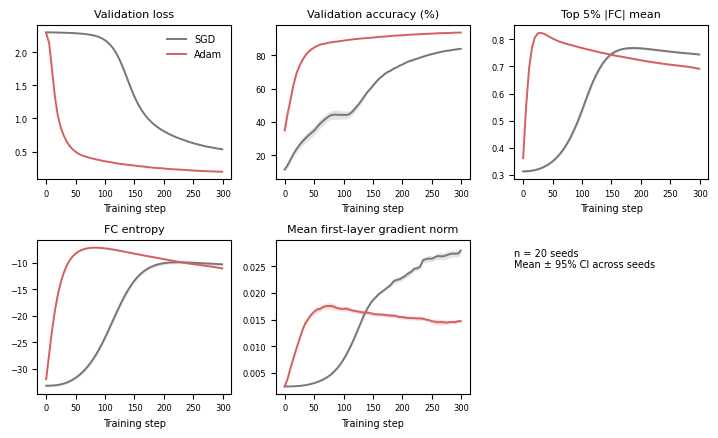

In [5]:
fig = plot_pair_curves(adam_results, experiment='adam', top_fc_ratio=TOP_FC_CURVE_RATIO)
export_figure(fig, OUTPUT_ROOT, 'Figure5g_Adam_multiseed_curves')
plt.show()

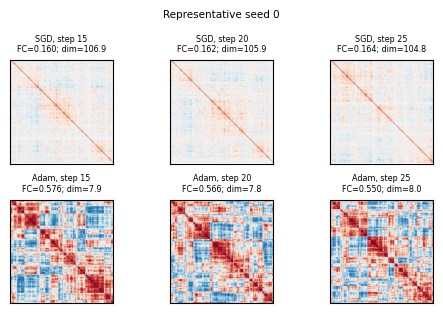

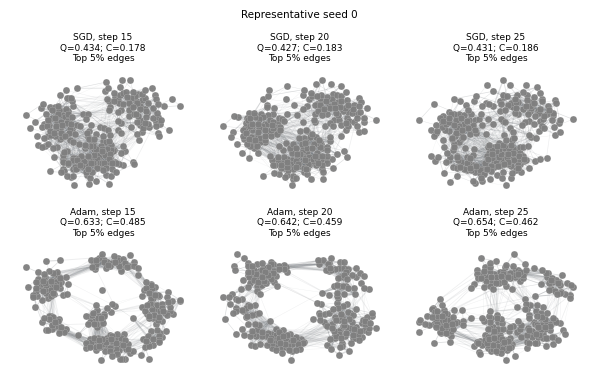

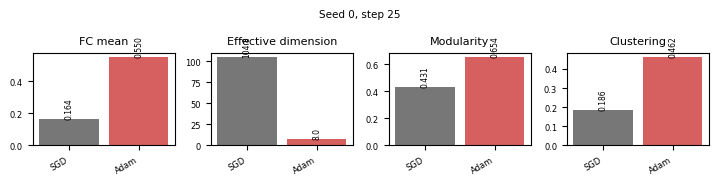

In [6]:
adam_labels = ('SGD', 'Adam')
fig = plot_representative_matrices(adam_representative, adam_labels, pair_config.fc_matrix_steps, REPRESENTATIVE_SEED)
export_figure(fig, OUTPUT_ROOT, 'Figure5g_Adam_representative_FC_matrices'); plt.show()
fig = plot_representative_networks(
    adam_representative, adam_labels, pair_config.fc_matrix_steps,
    REPRESENTATIVE_SEED, **NETWORK_PLOT_OPTIONS,
)
export_figure(fig, OUTPUT_ROOT, 'Figure5g_Adam_representative_networks'); plt.show()
fig = plot_representative_metric_bars(
    adam_representative, adam_labels, (STANDARD_COLOR, ADAM_COLOR),
    pair_config.metric_step, REPRESENTATIVE_SEED,
    top_ratio=NETWORK_TOP_EDGE_RATIO,
)
export_figure(fig, OUTPUT_ROOT, 'Figure5g_Adam_representative_metrics'); plt.show()

## Figure 5h | Without versus with BatchNorm

两种模型使用相同的SGD、线性层初始权重和minibatch；实验模型仅增加BatchNorm。

In [7]:
batchnorm_results, batchnorm_representative = run_or_load_pair_repeats(
    experiment='batchnorm', train_dataset=train_set,
    analysis_inputs=analysis_inputs, analysis_targets=analysis_targets,
    config=pair_config, result_dir=RESULT_ROOT, device=DEVICE,
    num_workers=NUM_WORKERS, overwrite=OVERWRITE_PAIR_RESULTS,
)
print('BatchNorm experiment seeds:', batchnorm_results['seeds'].tolist())

BatchNorm experiment seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


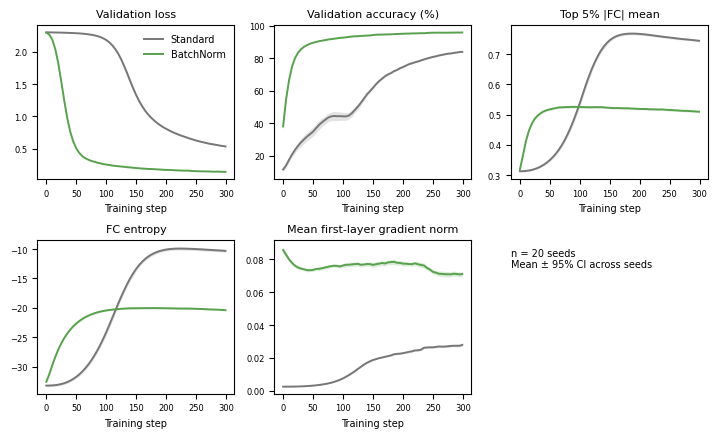

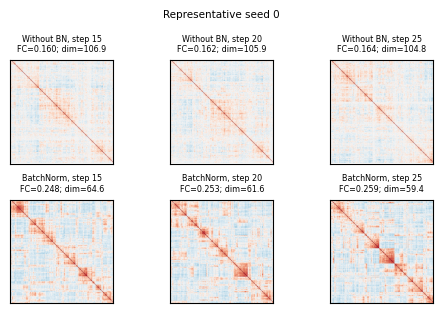

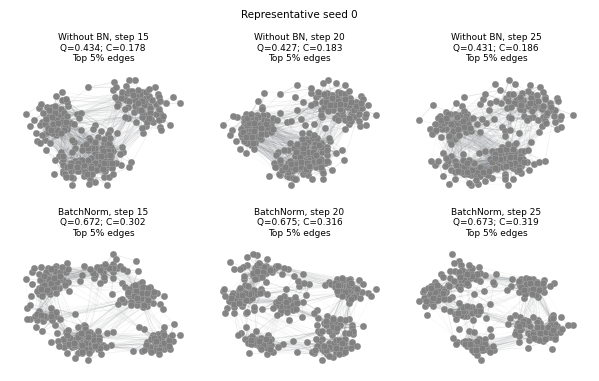

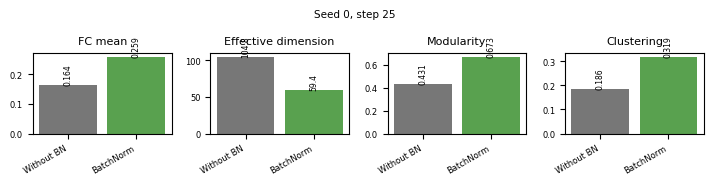

In [80]:
fig = plot_pair_curves(batchnorm_results, experiment='batchnorm', top_fc_ratio=TOP_FC_CURVE_RATIO)
export_figure(fig, OUTPUT_ROOT, 'Figure5h_BatchNorm_multiseed_curves')
plt.show()

batchnorm_labels = ('Without BN', 'BatchNorm')
fig = plot_representative_matrices(batchnorm_representative, batchnorm_labels, pair_config.fc_matrix_steps, REPRESENTATIVE_SEED)
export_figure(fig, OUTPUT_ROOT, 'Figure5h_BatchNorm_representative_FC_matrices'); plt.show()
fig = plot_representative_networks(
    batchnorm_representative, batchnorm_labels, pair_config.fc_matrix_steps,
    REPRESENTATIVE_SEED, **NETWORK_PLOT_OPTIONS,
)
export_figure(fig, OUTPUT_ROOT, 'Figure5h_BatchNorm_representative_networks'); plt.show()
fig = plot_representative_metric_bars(
    batchnorm_representative, batchnorm_labels, (STANDARD_COLOR, BATCHNORM_COLOR),
    pair_config.metric_step, REPRESENTATIVE_SEED,
    top_ratio=NETWORK_TOP_EDGE_RATIO,
)
export_figure(fig, OUTPUT_ROOT, 'Figure5h_BatchNorm_representative_metrics'); plt.show()

## Figure 5i | Residual and FC-guided residual networks

比较no residual、standard residual和FC-guided residual三种网络。三个模型在每个seed中使用相同的线性层初始化和训练minibatch。新版方法包含两个互补部分：rank-based positive boost保留并增强此前观察到的loss优势；FC-selected low-rank coupling把高FC单元的共享活动重新注入这些单元，以直接促进协同表示形成。所有神经元至少保留系数1的标准残差，且FC选择使用detach后的EMA统计。Figure 5i测量分类器实际接收的残差块输出，使干预层与FC报告层一致。

In [9]:
residual_results, residual_representative = run_or_load_residual_repeats(
    train_dataset=train_set, analysis_inputs=analysis_inputs,
    analysis_targets=analysis_targets, config=residual_config,
    result_dir=RESULT_ROOT, device=DEVICE, num_workers=NUM_WORKERS,
    overwrite=OVERWRITE_RESIDUAL_RESULTS,
)
print('Residual experiment seeds:', residual_results['seeds'].tolist())

# Descriptive multiseed summary; no result-dependent pass/fail assertions.
residual_steps = residual_results['steps']
residual_curves = residual_results['curves']
early_mask = residual_steps <= EARLY_FC_WINDOW_STEPS
loss_auc = np.trapz(residual_curves[:, :, 0], x=residual_steps, axis=2)
accuracy_auc = np.trapz(residual_curves[:, :, 1], x=residual_steps, axis=2)
early_fc_gain = residual_curves[:, :, 3, early_mask] - residual_curves[:, :, 3, 0, None]
early_fc_gain_auc = np.trapz(early_fc_gain, x=residual_steps[early_mask], axis=2)
loss_advantage = loss_auc[:, 1] - loss_auc[:, 2]
accuracy_advantage = accuracy_auc[:, 2] - accuracy_auc[:, 1]
fc_advantage = early_fc_gain_auc[:, 2] - early_fc_gain_auc[:, 1]
loss_success = float(np.mean(loss_advantage > 0))
accuracy_success = float(np.mean(accuracy_advantage > 0))
fc_success = float(np.mean(fc_advantage > 0))
print({
    'mean_standard_minus_FC_loss_AUC': float(loss_advantage.mean()),
    'mean_FC_minus_standard_accuracy_AUC': float(accuracy_advantage.mean()),
    'mean_FC_minus_standard_early_FC_gain_AUC': float(fc_advantage.mean()),
    'loss_positive_seed_fraction': loss_success,
    'accuracy_positive_seed_fraction': accuracy_success,
    'early_FC_positive_seed_fraction': fc_success,
})

Residual experiment seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
{'mean_standard_minus_FC_loss_AUC': 67.61868086755275, 'mean_FC_minus_standard_accuracy_AUC': 1117.6947237491609, 'mean_FC_minus_standard_early_FC_gain_AUC': 4.177727602606151, 'loss_positive_seed_fraction': 1.0, 'accuracy_positive_seed_fraction': 1.0, 'early_FC_positive_seed_fraction': 1.0}


/tmp/ipykernel_167198/1973114585.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  loss_auc = np.trapz(residual_curves[:, :, 0], x=residual_steps, axis=2)
/tmp/ipykernel_167198/1973114585.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  accuracy_auc = np.trapz(residual_curves[:, :, 1], x=residual_steps, axis=2)
/tmp/ipykernel_167198/1973114585.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  early_fc_gain_auc = np.trapz(early_fc_gain, x=residual_steps[early_mask], axis=2)


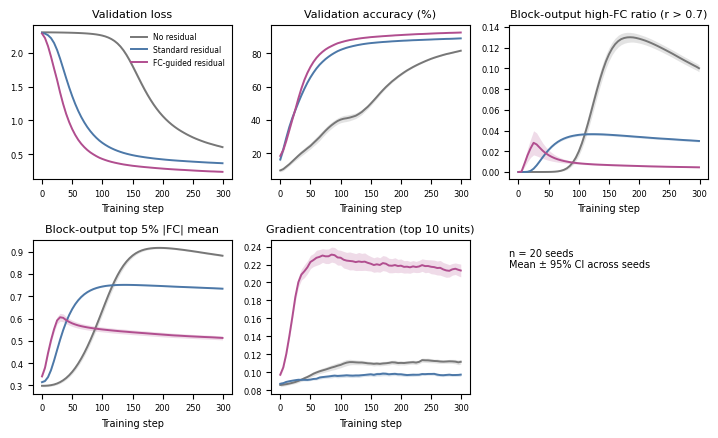

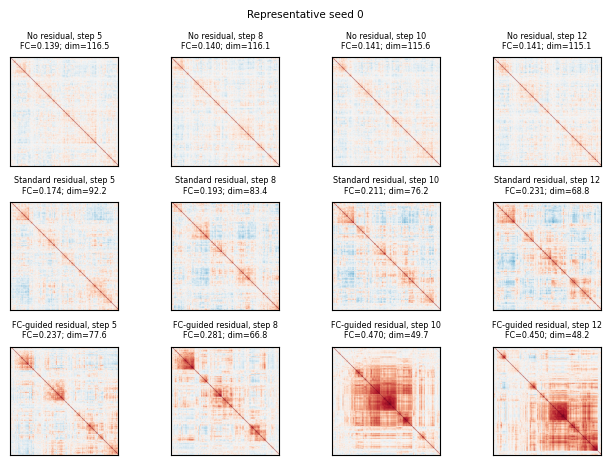

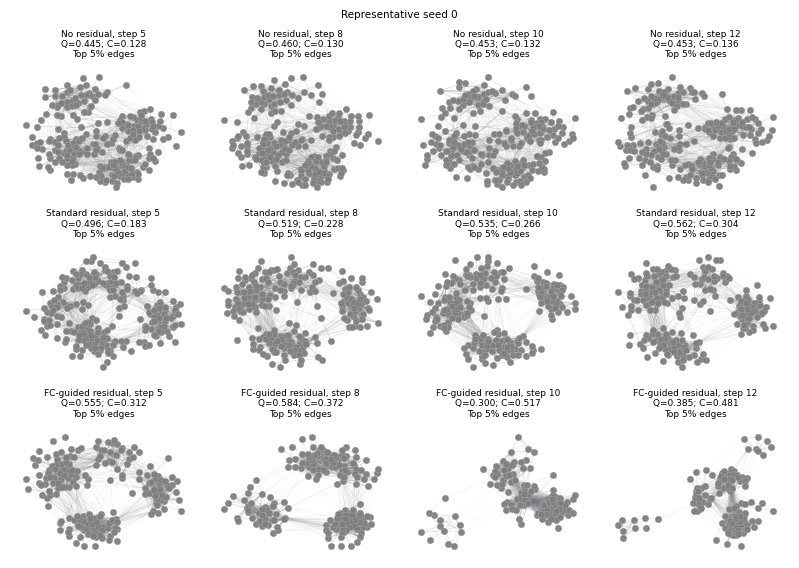

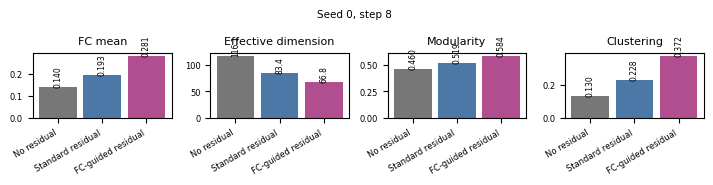

In [83]:
fig = plot_residual_curves(residual_results, top_fc_ratio=TOP_FC_CURVE_RATIO)
export_figure(fig, OUTPUT_ROOT, 'Figure5i_Residual_multiseed_curves')
plt.show()

residual_labels = ('No residual', 'Standard residual', 'FC-guided residual')
residual_colors = (PLAIN_COLOR, RESIDUAL_COLOR, FC_RESIDUAL_COLOR)
fig = plot_representative_matrices(residual_representative, residual_labels, residual_config.fc_matrix_steps, REPRESENTATIVE_SEED)
export_figure(fig, OUTPUT_ROOT, 'Figure5i_Residual_representative_FC_matrices'); plt.show()
fig = plot_representative_networks(
    residual_representative, residual_labels, residual_config.fc_matrix_steps,
    REPRESENTATIVE_SEED, **NETWORK_PLOT_OPTIONS,
)
export_figure(fig, OUTPUT_ROOT, 'Figure5i_Residual_representative_networks'); plt.show()
fig = plot_representative_metric_bars(
    residual_representative, residual_labels, residual_colors,
    residual_config.metric_step, REPRESENTATIVE_SEED,
    top_ratio=NETWORK_TOP_EDGE_RATIO,
)
export_figure(fig, OUTPUT_ROOT, 'Figure5i_Residual_representative_metrics'); plt.show()

## Integrity checks and reporting

曲线的独立重复单位是完整训练seed，不是训练step、神经元或FC边。图注应写明 `n = 20 independently initialized and trained networks; curves show mean ± 95% CI across seeds`。矩阵、网络和柱状图应注明 `representative seed = 0`，不能对单次柱状图做组水平显著性推断。

In [11]:
for name, result, n_models in [
    ('Adam', adam_results, 2),
    ('BatchNorm', batchnorm_results, 2),
    ('Residual', residual_results, 3),
]:
    print(name, 'seeds =', len(result['seeds']), '| curves =', result['curves'].shape)
print('Cached results:', RESULT_ROOT)
print('Exported figures:', OUTPUT_ROOT)

Adam seeds = 20 | curves = (20, 2, 5, 61)
BatchNorm seeds = 20 | curves = (20, 2, 5, 61)
Residual seeds = 20 | curves = (20, 3, 5, 61)
Cached results: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/results/Figure5g_i_multiseed
Exported figures: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/Figure5g_i_multiseed
